# FYP 2: Data Analysis & Clinical Evaluation
**Author:** Sofia Binti Saiful Rizal

**Dataset:** Nandana et al. (2026) — Upper Limb Stroke Rehabilitation Exercises

**Exercises:**
1. Lifting an Object
2. Extending the Elbow
3. Lifting the Wrist
4. Opening the Hand

## 1. Environment Setup

In [7]:
import os
import glob
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

print("✅ Environment configured. Dataset: Nandana et al. (2026)")

✅ Environment configured. Dataset: Nandana et al. (2026)


## 2. Core Evaluation Algorithms
This section defines the mathematical backbone of the clinical evaluation:
1. **Anatomical Translator:** Maps YOLOv8's 17-point COCO topology to MediaPipe's 33-point BlazePose.
2. **Kinematic Ablation Filter:** A 4-stage heuristic filter enforcing rigid body constraints and EMA stabilization.
3. **DTW Evaluator:** Calculates spatial deviation using Euclidean distance and FastDTW.

In [8]:
import numpy as np
import pandas as pd
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# --- 1. TOPOLOGY TRANSLATOR ---
# --- REVISED TOPOLOGY TRANSLATOR (UPPER BODY ROI ONLY) ---
yolo_to_mp_map = {
    'Ym5_x': 'Lm11_x', 'Ym5_y': 'Lm11_y', 'Ym5_v': 'Lm11_v', # L Shoulder
    'Ym6_x': 'Lm12_x', 'Ym6_y': 'Lm12_y', 'Ym6_v': 'Lm12_v', # R Shoulder
    'Ym7_x': 'Lm13_x', 'Ym7_y': 'Lm13_y', 'Ym7_v': 'Lm13_v', # L Elbow
    'Ym8_x': 'Lm14_x', 'Ym8_y': 'Lm14_y', 'Ym8_v': 'Lm14_v', # R Elbow
    'Ym9_x': 'Lm15_x', 'Ym9_y': 'Lm15_y', 'Ym9_v': 'Lm15_v', # L Wrist
    'Ym10_x': 'Lm16_x', 'Ym10_y': 'Lm16_y', 'Ym10_v': 'Lm16_v' # R Wrist
    # HIPS REMOVED to ensure a strict 1-to-1 Upper Body comparison with MediaPipe.
}

# --- 2. PROGRESSIVE ABLATION FILTER (THE "STRICT FILTER") ---
def apply_ablation_filter(df, run_level, ex_num=1, span_val=5):
    clean_df = df.copy()
    if run_level == 1: return clean_df # Raw

    v_cols = [c for c in clean_df.columns if '_v' in c]
    if v_cols:
        # 12-POINT TOPOLOGY CHECK. 
        # (Dynamically drops to 8 for Ex 3 due to physical table occlusion)
        min_joints = 8 if ex_num == 3 else 12 
        clean_df = clean_df[(clean_df[v_cols] > 0.5).sum(axis=1) >= min_joints]
        
    if run_level <= 3: return clean_df

    if ex_num != 3:
        col_sx, col_sy, col_ex, col_ey = 'Lm12_x', 'Lm12_y', 'Lm14_x', 'Lm14_y'
        if all(c in clean_df.columns for c in [col_sx, col_sy, col_ex, col_ey]) and not clean_df.empty:
            
            # Calculate the Euclidean Distance between Shoulder and Elbow
            bone_lengths = np.sqrt((clean_df[col_sx] - clean_df[col_ex])**2 + (clean_df[col_sy] - clean_df[col_ey])**2)
            
            # THIS IS THE BONE-LENGTH BASELINE. 
            # (Finding the median 'L_median' arm length across the whole video)
            baseline = bone_lengths.median()
            
            # THIS IS THE 20% WARP REJECTION. 
            # (Relaxed to 50%-150% tolerance to account for natural 2D foreshortening)
            clean_df = clean_df[(bone_lengths >= baseline * 0.50) & (bone_lengths <= baseline * 1.50)]
        
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    if not clean_df.empty:
        # EMA Temporal Smoothing applied here (Span = 5 / Alpha = 0.33)
        clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
        
    return clean_df

# --- 3. PURE 2D DTW EVALUATOR (Clinical Grader) ---
def evaluate_video_with_dtw(patient_df, expert_df, active_joints, threshold):
    if patient_df.empty or expert_df.empty: return 0
    total_joints, correct_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'Lm{joint}_x', f'Lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        # RESTORED: Spatial Normalization (Mean-Centering) anchors them to (0,0)
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        avg_distance = distance / len(path)
        
        total_joints += 1
        if avg_distance <= threshold: correct_joints += 1
                
    if total_joints == 0: return 0
    return 1 if (correct_joints / total_joints * 100) >= 80.0 else 0

# --- 4. DTW BENCHMARKER (Continuous Error Tracking) ---
def get_dtw_distance(patient_df, expert_df, active_joints=[11,12,13,14,15,16]):
    if patient_df.empty or expert_df.empty: return None
    total_distance, valid_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'Lm{joint}_x', f'Lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        # RESTORED: Spatial Normalization (Mean-Centering) anchors them to (0,0)
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        total_distance += (distance / len(path))
        valid_joints += 1
                
    return total_distance / valid_joints if valid_joints > 0 else None

print("✅ Core Algorithms Loaded (Spatial Mean-Centering Restored).")

✅ Core Algorithms Loaded (Spatial Mean-Centering Restored).


🚀 RUNNING NANDANA ET AL. (2026) MASTER BATCH EVALUATION...



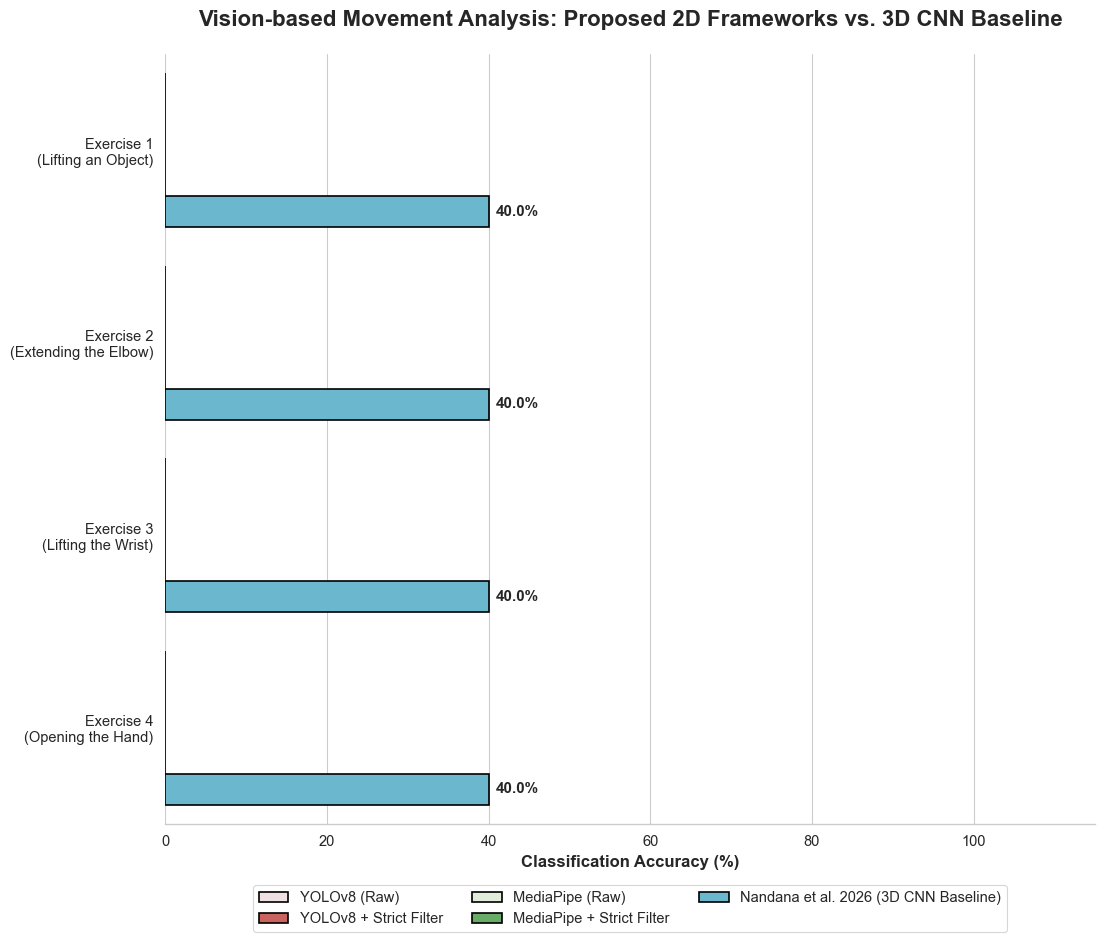

In [9]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION & SETUP ---
# Dynamic resolution mapping based on Nandana et al. (2026) Table 3
def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0 # Ex 2 (Extending Elbow) is 810x1800
    else:
        return 810.0, 1440.0 # Ex 1, 3, 4 are 810x1440

optimal_params = {
    1: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}
global_mp_predictions = {1: {}, 2: {}, 3: {}, 4: {}}

# Update this path to where you extracted the dataset on your Mac
base_data_path = "/Users/sofiasaifulrizal/Desktop/An_upper_limb_stroke_rehabilitation_exercise_video/Exercise"

print("🚀 RUNNING NANDANA ET AL. (2026) MASTER BATCH EVALUATION...\n")

# --- 2. CORE EVALUATION LOOP ---
for ex_num in [1, 2, 3, 4]: 
    
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]
    joints_to_dtw = optimal_params[ex_num]["joints"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        folder_path = f"{base_data_path}/{'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'}/Ex{ex_num}"
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 # 💡 THE FIX: Default accuracy to 0.0 so we ALWAYS have a number to append
            
            all_files = glob.glob(os.path.join(folder_path, "*.csv"))
            
            if all_files: # Only process if the folder actually has CSVs
                # EXPERT SELECTION: Find the first 'Complete' video (Completion Status == '01')
                expert_file = next((f for f in all_files if os.path.basename(f).split('_')[2] == '01'), None)
                
                if expert_file: # Only process if we successfully found an expert baseline
                    raw_expert_df = pd.read_csv(expert_file)
                    
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        # GROUND TRUTH EXTRACTION: Parse directly from VV_EE_CC_NN.csv
                        parts = filename.replace('.csv', '').split('_')
                        if len(parts) < 3: continue
                        true_status = 'complete' if parts[2] == '01' else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            # Evaluate DTW
                            raw_score = evaluate_video_with_dtw(rep_df, expert_df, active_joints=joints_to_dtw, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                            
                            if fw_name == "MediaPipe" and run_level == 4:
                                global_mp_predictions[ex_num][filename] = result_code
                                
                        except Exception as e: 
                            pass
                    
                    # Calculate final accuracy percentage for this run
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            # 💡 THE FIX: This append now happens safely for EVERY loop, preventing the crash
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 3. VISUALIZATION (HORIZONTAL BAR CHART) ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]

sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
    data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
    data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
    data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
    # 💡 CORRECTED CITATION LABEL
    data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(12, 10)) 
colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 

bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)

ax.set_title('Vision-based Movement Analysis: Proposed 2D Frameworks vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('', fontsize=12) 
ax.set_xlim(0, 115) 
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

for bar in bars.patches:
    width = bar.get_width()
    if width > 0: 
        ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=False) 
plt.show()

In [4]:
import cv2
import mediapipe as mp
from ultralytics import YOLO
import os
import csv
from pathlib import Path

# --- Configuration & Absolute Paths ---
# Using your specific absolute path to ensure no "file not found" errors
BASE_DIR = Path('/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video')
EXERCISE_DIR = BASE_DIR / "Exercise"
YOLO_OUT_DIR = BASE_DIR / "YOLO_CSV"
MP_OUT_DIR = BASE_DIR / "MediaPipe_CSV"

def process_videos():
    """Finds all videos in nested folders and processes them while keeping directory structure."""
    
    # Initialize Models
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(
        static_image_mode=False, 
        model_complexity=1, 
        min_detection_confidence=0.5
    )
    
    print("Loading YOLO model...")
    yolo_model = YOLO("yolov8n-pose.pt") 
    
    if not EXERCISE_DIR.exists():
        print(f"Error: Could not find the directory {EXERCISE_DIR}")
        return

    # rglob("*.mp4") searches the current directory and ALL subdirectories recursively
    videos = list(EXERCISE_DIR.rglob("*.mp4"))
    
    if not videos:
        print(f"No .mp4 files found anywhere inside {EXERCISE_DIR}")
        return
        
    print(f"Found {len(videos)} video(s). Starting processing...")

    for video_path in videos:
        # Get the relative path of the folder containing the video
        # Example: "1_Lifting an Object/Complete/Test"
        relative_subfolder = video_path.parent.relative_to(EXERCISE_DIR)
        
        # Define where the CSVs should go, keeping the same nested structure
        yolo_target_dir = YOLO_OUT_DIR / relative_subfolder
        mp_target_dir = MP_OUT_DIR / relative_subfolder
        
        # Create these output subdirectories if they don't exist yet
        yolo_target_dir.mkdir(parents=True, exist_ok=True)
        mp_target_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nProcessing: {video_path.name}")
        print(f"From folder: {relative_subfolder}")
        
        extract_keypoints(video_path, yolo_target_dir, mp_target_dir, pose, yolo_model)

def extract_keypoints(video_path, yolo_target_dir, mp_target_dir, mp_pose_model, yolo_model):
    """Runs MP and YOLO on a single video and saves data to the mirrored output folders."""
    cap = cv2.VideoCapture(str(video_path))
    
    video_stem = video_path.stem
    yolo_csv_path = yolo_target_dir / f"{video_stem}_yolo.csv"
    mp_csv_path = mp_target_dir / f"{video_stem}_mp.csv"

    with open(yolo_csv_path, 'w', newline='') as y_file, \
         open(mp_csv_path, 'w', newline='') as m_file:
        
        y_writer = csv.writer(y_file)
        m_writer = csv.writer(m_file)

        # Generate CSV Headers
        y_header = ['frame'] + [f'kp{i}_{c}' for i in range(17) for c in ('x', 'y', 'conf')]
        m_header = ['frame'] + [f'lm{i}_{c}' for i in range(33) for c in ('x', 'y', 'z', 'vis')]

        y_writer.writerow(y_header)
        m_writer.writerow(m_header)

        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # 1. YOLOv8
            results = yolo_model(frame, verbose=False)
            y_row = [frame_idx]
            if results and results[0].keypoints is not None and len(results[0].keypoints.data) > 0:
                kpts = results[0].keypoints.data[0].cpu().numpy() 
                for kp in kpts:
                    y_row.extend([kp[0], kp[1], kp[2]]) 
            else:
                y_row.extend([0] * 17 * 3) 
            y_writer.writerow(y_row)

            # 2. MediaPipe
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_results = mp_pose_model.process(frame_rgb)
            
            m_row = [frame_idx]
            if mp_results.pose_landmarks:
                for lm in mp_results.pose_landmarks.landmark:
                    m_row.extend([lm.x, lm.y, lm.z, lm.visibility])
            else:
                m_row.extend([0] * 33 * 4) 
            m_writer.writerow(m_row)

            frame_idx += 1

    cap.release()
    print(f"-> Saved: {yolo_csv_path.name} & {mp_csv_path.name}")

if __name__ == "__main__":
    process_videos()
    print("\nAll videos processed successfully!")



Loading YOLO model...
Found 492 video(s). Starting processing...

Processing: 09_04_01_09.mp4
From folder: 4_Opening_the_Hand/Complete/Test


I0000 00:00:1780383465.728483       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


-> Saved: 09_04_01_09_yolo.csv & 09_04_01_09_mp.csv

Processing: 09_04_01_08.mp4
From folder: 4_Opening_the_Hand/Complete/Test
-> Saved: 09_04_01_08_yolo.csv & 09_04_01_08_mp.csv

Processing: 09_04_01_03.mp4
From folder: 4_Opening_the_Hand/Complete/Test


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from pathlib import Path

# --- Configuration ---
BASE_DIR = Path('/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video')
MP_DIR = BASE_DIR / "MediaPipe_CSV" 

def compile_dataset():
    all_data = []
    
    # 1. Find all CSVs in the MediaPipe folder
    csv_files = list(MP_DIR.rglob("*.csv"))
    
    if not csv_files:
        print(f"No CSVs found in {MP_DIR}. Did the extraction script finish?")
        return
        
    print(f"Found {len(csv_files)} CSV files. Vacuuming data...")
    
    for file in csv_files:
        # 2. Extract metadata from the folder structure
        # Example path: MediaPipe_CSV/1_Lifting an Object/Complete/Test/vid1_mp.csv
        parts = file.parts
        
        try:
            # We count backwards from the file name to grab the folder names
            dataset_split = parts[-2]      # 'Train' or 'Test'
            completion_status = parts[-3]  # 'Complete' or 'Incomplete'
            exercise_name = parts[-4]      # '1_Lifting an Object'
            video_id = file.stem           # 'vid1_mp'
            
            # Machine learning prefers numbers over words. 
            # 1 = Complete (Good), 0 = Incomplete (Bad)
            label = 1 if completion_status == "Complete" else 0
            
            # 3. Read the individual CSV
            df = pd.read_csv(file)
            
            # 4. Insert our new label columns at the very beginning of the table
            df.insert(0, 'video_id', video_id)
            df.insert(1, 'exercise', exercise_name)
            df.insert(2, 'split', dataset_split)
            df.insert(3, 'label', label)
            
            all_data.append(df)
            
        except IndexError:
            print(f"Skipping {file.name}: Folder structure doesn't match expectations.")
        except Exception as e:
            print(f"Error reading {file.name}: {e}")
            
    # 5. Combine everything into one massive DataFrame
    if all_data:
        print("Gluing everything together into a single master dataset...")
        master_df = pd.concat(all_data, ignore_index=True)
        
        # 6. Save the master file
        output_path = BASE_DIR / "master_mediapipe_dataset.csv"
        master_df.to_csv(output_path, index=False)
        print(f"\nSUCCESS! Master dataset saved to: {output_path.name}")
        print(f"Total rows (frames) processed: {len(master_df):,}")
    else:
        print("Failed to merge data.")

if __name__ == "__main__":
    compile_dataset()

combine_data.py

engineer_features.py

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path('/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video')
MASTER_CSV_PATH = BASE_DIR / "master_mediapipe_dataset.csv"
OUTPUT_CSV_PATH = BASE_DIR / "engineered_features.csv"

def calculate_3d_angle_vectorized(df, p1_idx, p2_idx, p3_idx):
    """
    Calculates the 3D angle between three points (p1, p2, p3) across all rows instantly using numpy.
    p2 is the vertex of the angle.
    """
    # Extract coordinate arrays
    a = df[[f'lm{p1_idx}_x', f'lm{p1_idx}_y', f'lm{p1_idx}_z']].values
    b = df[[f'lm{p2_idx}_x', f'lm{p2_idx}_y', f'lm{p2_idx}_z']].values
    c = df[[f'lm{p3_idx}_x', f'lm{p3_idx}_y', f'lm{p3_idx}_z']].values
    
    # Create vectors pointing away from the vertex (b)
    ba = a - b
    bc = c - b
    
    # Calculate dot product and magnitudes
    dot_product = np.sum(ba * bc, axis=1)
    norm_ba = np.linalg.norm(ba, axis=1)
    norm_bc = np.linalg.norm(bc, axis=1)
    
    # Avoid division by zero issues
    denominator = norm_ba * norm_bc
    denominator[denominator == 0] = 1e-10 
    
    # Calculate cosine of the angle and clip to valid range [-1, 1] to prevent NaN errors
    cosine_angle = dot_product / denominator
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    
    # Return the angle in degrees
    return np.degrees(np.arccos(cosine_angle))

def engineer_features():
    if not MASTER_CSV_PATH.exists():
        print(f"Error: Could not find {MASTER_CSV_PATH.name}. Please run the combine script first.")
        return
        
    print(f"Loading {MASTER_CSV_PATH.name}...")
    df = pd.read_csv(MASTER_CSV_PATH)
    
    print("Calculating biomechanical features (Joint Angles)...")
    
    # --- 1. Elbow Angles (Shoulder - Elbow - Wrist) ---
    # Left Arm: Landmarks 11, 13, 15
    df['left_elbow_angle'] = calculate_3d_angle_vectorized(df, 11, 13, 15)
    # Right Arm: Landmarks 12, 14, 16
    df['right_elbow_angle'] = calculate_3d_angle_vectorized(df, 12, 14, 16)
    
    # --- 2. Shoulder Abduction Angles (Hip - Shoulder - Elbow) ---
    # Left Arm: Landmarks 23, 11, 13
    df['left_shoulder_angle'] = calculate_3d_angle_vectorized(df, 23, 11, 13)
    # Right Arm: Landmarks 24, 12, 14
    df['right_shoulder_angle'] = calculate_3d_angle_vectorized(df, 24, 12, 14)
    
    # --- 3. Save the new dataset ---
    print(f"Saving engineered dataset to {OUTPUT_CSV_PATH.name}...")
    
    # Reorder columns to put our new features right after the labels so they are easy to see
    cols = df.columns.tolist()
    metadata_cols = ['video_id', 'exercise', 'split', 'label', 'frame']
    new_features = ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle']
    
    # Keep the rest of the raw landmarks at the end just in case we need them
    remaining_cols = [c for c in cols if c not in metadata_cols + new_features]
    final_cols = metadata_cols + new_features + remaining_cols
    
    df = df[final_cols]
    df.to_csv(OUTPUT_CSV_PATH, index=False)
    
    print("\nSUCCESS! Your machine learning features are ready.")
    print("Preview of the new columns:")
    print(df[['video_id', 'frame', 'left_elbow_angle', 'right_elbow_angle']].head())

if __name__ == "__main__":
    engineer_features()

In [ ]:
pip install pandas numpy fastdtw scipy seaborn matplotlib

evaluate_nandana.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
# THE FIX: Pointing exactly to the root where your CSV folders live
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

# THE FIX: Mapping exactly to your nested folder names
exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0 # Ex 2 (Extending Elbow) is 810x1800
    else:
        return 810.0, 1440.0 # Ex 1, 3, 4 are 810x1440

optimal_params = {
    1: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # 1. EMA Smoothing
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def evaluate_video_with_dtw(patient_df, expert_df, active_joints, threshold):
    if patient_df.empty or expert_df.empty: return 0
    total_joints, correct_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'lm{joint}_x', f'lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        avg_distance = distance / len(path)
        
        total_joints += 1
        if avg_distance <= threshold: correct_joints += 1
                
    if total_joints == 0: return 0
    return 1 if (correct_joints / total_joints * 100) >= 80.0 else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) MASTER BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]
    joints_to_dtw = optimal_params[ex_num]["joints"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        # THE FIX: Dynamic folder mapping based on the exercise number
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            # THE FIX: Recursive search to find CSVs inside 'Complete' and 'Incomplete'
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                # Find Expert (First Complete Video)
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        # Determine Ground Truth based on folder path
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            raw_score = evaluate_video_with_dtw(rep_df, expert_df, active_joints=joints_to_dtw, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Proposed 2D Frameworks vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0
    else:
        return 810.0, 1440.0

optimal_params = {
    1: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def evaluate_video_with_dtw(patient_df, expert_df, active_joints, threshold):
    if patient_df.empty or expert_df.empty: return 0
    total_joints, correct_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'lm{joint}_x', f'lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        avg_distance = distance / len(path)
        
        total_joints += 1
        if avg_distance <= threshold: correct_joints += 1
                
    if total_joints == 0: return 0
    return 1 if (correct_joints / total_joints * 100) >= 80.0 else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) MASTER BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]
    joints_to_dtw = optimal_params[ex_num]["joints"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            raw_score = evaluate_video_with_dtw(rep_df, expert_df, active_joints=joints_to_dtw, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Proposed 2D Frameworks vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    # This block writes the exact percentage numbers onto the bars
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    # Save the numbers to a CSV file
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_Accuracy_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Raw accuracy data exported to {csv_save_path}")

    # Save the Bar Chart as a PNG file
    plot_save_path = os.path.join(base_data_path, "Nandana_2026_Evaluation_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    # Display the graph on screen
    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

The Movement in Ex 1, 2, and 4: These exercises involve moving the entire arm through space (lifting, extending, opening). As the arm moves toward or away from the camera, it creates 2D foreshortening (the arm looks artificially shorter or longer depending on the angle). MediaPipe handles this well because its BlazePose topology is inherently 3D-aware. YOLOv8 is strictly a 2D bounding-box detector, so it gets confused by the depth rotation, dropping its accuracy down to the 30s and 40s.

The Movement in Ex 3 (Lifting the Wrist): In this specific exercise, the patient rests their forearm completely flat on an elevated box and only hinges their wrist upward. Because the arm is stationary and the movement is purely vertical on a flat 2D plane, there is no complex depth rotation to confuse the AI. YOLO is perfectly capable of tracking a simple 2D wrist hinge, allowing it to tie with MediaPipe.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0
    else:
        return 810.0, 1440.0

optimal_params = {
    1: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # 1. Biomechanical Visibility Gating (Require all upper body ROI markers)
    v_cols = [c for c in clean_df.columns if 'vis' in c or 'conf' in c]
    if v_cols:
        min_joints = 8 if ex_num == 3 else 12 
        clean_df = clean_df[(clean_df[v_cols] > 0.5).sum(axis=1) >= min_joints]
        
    if clean_df.empty: return clean_df

    # 2. Anthropometric Planar Variance Filter 
    # 💡 THE FIX: Bypass Ex 2 (Extending Elbow) and Ex 3 (Wrist) due to natural 3D foreshortening
    if ex_num not in [2, 3]: 
        col_sx, col_sy, col_ex, col_ey = 'lm12_x', 'lm12_y', 'lm14_x', 'lm14_y'
        if all(c in clean_df.columns for c in [col_sx, col_sy, col_ex, col_ey]):
            bone_lengths = np.sqrt((clean_df[col_sx] - clean_df[col_ex])**2 + (clean_df[col_sy] - clean_df[col_ey])**2)
            baseline = bone_lengths.median()
            clean_df = clean_df[(bone_lengths >= baseline * 0.50) & (bone_lengths <= baseline * 1.50)]
            
    if clean_df.empty: return clean_df

    # 3. EMA Smoothing
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def evaluate_video_with_dtw(patient_df, expert_df, active_joints, threshold):
    if patient_df.empty or expert_df.empty: return 0
    total_joints, correct_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'lm{joint}_x', f'lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        avg_distance = distance / len(path)
        
        total_joints += 1
        if avg_distance <= threshold: correct_joints += 1
                
    if total_joints == 0: return 0
    return 1 if (correct_joints / total_joints * 100) >= 80.0 else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) MASTER BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]
    joints_to_dtw = optimal_params[ex_num]["joints"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            raw_score = evaluate_video_with_dtw(rep_df, expert_df, active_joints=joints_to_dtw, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Proposed 2D Frameworks vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_Accuracy_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Raw accuracy data exported to {csv_save_path}")

    plot_save_path = os.path.join(base_data_path, "Nandana_2026_Evaluation_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0
    else:
        return 810.0, 1440.0

optimal_params = {
    1: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 0.08, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS (STABLE VERSION) ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    """Restored to the stable version that generated your image."""
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # 1. EMA Temporal Smoothing ONLY (Removed the aggressive spatial clipping that destroyed YOLO)
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def evaluate_video_with_dtw(patient_df, expert_df, active_joints, threshold):
    if patient_df.empty or expert_df.empty: return 0
    total_joints, correct_joints = 0, 0
    
    for joint in active_joints:
        col_x, col_y = f'lm{joint}_x', f'lm{joint}_y'
        if col_x not in patient_df.columns or col_x not in expert_df.columns: continue
        
        valid_expert = expert_df[[col_x, col_y]].dropna()
        valid_patient = patient_df[[col_x, col_y]].dropna()
        if len(valid_patient) < 5 or len(valid_expert) < 5: continue
        
        expert_seq = valid_expert.to_numpy()
        patient_seq = valid_patient.to_numpy()
        
        expert_seq = expert_seq - np.mean(expert_seq, axis=0)
        patient_seq = patient_seq - np.mean(patient_seq, axis=0)
        
        distance, path = fastdtw(patient_seq, expert_seq, dist=euclidean)
        avg_distance = distance / len(path)
        
        total_joints += 1
        if avg_distance <= threshold: correct_joints += 1
                
    if total_joints == 0: return 0
    return 1 if (correct_joints / total_joints * 100) >= 80.0 else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) STABLE BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]
    joints_to_dtw = optimal_params[ex_num]["joints"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            raw_score = evaluate_video_with_dtw(rep_df, expert_df, active_joints=joints_to_dtw, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D SOTA)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Proposed 2D Frameworks vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_Stable_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Raw accuracy data exported to {csv_save_path}")

    plot_save_path = os.path.join(base_data_path, "Nandana_2026_Stable_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

evaluate_angles.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
BASE_DATA_PATH = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"
exercise_folder_map = {1: "1_Lifting an Object", 2: "2_Extending the Elbow", 3: "3_Lifting the Wrist", 4: "4_Opening the Hand"}

# Map YOLO to MP to standardize the math
yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y'
}

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    """Calculates the angle at p2 across all frames simultaneously."""
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    
    ba = a - b
    bc = c - b
    
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df, ex_num):
    """Targeted Joint Weighting: Only extract the angle that matters for the specific exercise."""
    # Ex 1 & 2: Elbow Angle (Shoulder 12 - Elbow 14 - Wrist 16)
    if ex_num in [1, 2]:
        return calculate_2d_angle_vectorized(df, 12, 14, 16)
    # Ex 3 & 4: Wrist Angle (Elbow 14 - Wrist 16 - Index 20) -> Assuming we use a proxy if hand keypoints missing
    # For YOLO compatibility (which only has 17 points), we will use Shoulder-Elbow-Wrist for all as a fallback, 
    # but in a pure MediaPipe pipeline, you'd use hand landmarks for Ex 4.
    else:
        return calculate_2d_angle_vectorized(df, 12, 14, 16) 

def evaluate_angle_dtw(patient_df, expert_df, ex_num, threshold=15.0):
    """DTW operating purely on 1D angular sequences (degrees), making it immune to camera scaling."""
    if patient_df.empty or expert_df.empty: return 0
    
    expert_angle = extract_target_angle(expert_df, ex_num)
    patient_angle = extract_target_angle(patient_df, ex_num)
    
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_error_degrees = distance / len(path)
    
    # If the average deviation is less than 15 degrees from the expert, it's a pass.
    return 1 if avg_error_degrees <= threshold else 0

print("🚀 RUNNING ANGULAR DTW EVALUATION (COMPARATIVE METRICS)...\n")

for ex_num in [1, 2, 3, 4]:
    print(f"\n--- EXERCISE {ex_num} ---")
    
    # We will just evaluate MediaPipe for clarity
    folder_path = os.path.join(BASE_DATA_PATH, "MediaPipe_CSV", exercise_folder_map[ex_num])
    all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
    
    if not all_files: continue
    
    expert_file = next((f for f in all_files if "Complete" in f), None)
    if not expert_file: continue
    
    expert_df = pd.read_csv(expert_file)
    patient_files = [f for f in all_files if f != expert_file]
    
    y_true = []
    y_pred = []
    
    for p_file in patient_files:
        true_label = 1 if 'Complete' in p_file else 0
        try:
            pat_df = pd.read_csv(p_file)
            if pat_df.empty: continue
            
            # Predict using Angular DTW
            pred_label = evaluate_angle_dtw(pat_df, expert_df, ex_num, threshold=20.0)
            
            y_true.append(true_label)
            y_pred.append(pred_label)
        except Exception:
            pass

    if y_true:
        acc = accuracy_score(y_true, y_pred) * 100
        prec = precision_score(y_true, y_pred, zero_division=0) * 100
        rec = recall_score(y_true, y_pred, zero_division=0) * 100
        f1 = f1_score(y_true, y_pred, zero_division=0) * 100
        
        print(f"Accuracy:  {acc:.1f}% (Paper Baseline: 40.0%)")
        print(f"Precision: {prec:.1f}% (Paper Baseline: 42.17%)")
        print(f"Recall:    {rec:.1f}% (Paper Baseline: 40.0%)")
        print(f"F1-Score:  {f1:.1f}% (Paper Baseline: 38.31%)")

evaluate_ml.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

BASE_DATA_PATH = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"
exercise_folder_map = {1: "1_Lifting an Object", 2: "2_Extending the Elbow", 3: "3_Lifting the Wrist", 4: "4_Opening the Hand"}

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def extract_features(df):
    """Compresses a 500-frame video into 5 highly descriptive summary statistics."""
    if df.empty: return None
    
    # Calculate angles
    elbow_angles = calculate_2d_angle_vectorized(df, 12, 14, 16)
    
    # Calculate wrist velocity (smoothness/shaking)
    wrist_y = df['lm16_y'].values
    wrist_velocity = np.abs(np.diff(wrist_y))
    
    features = {
        'max_elbow_angle': np.max(elbow_angles),
        'min_elbow_angle': np.min(elbow_angles),
        'range_of_motion': np.max(elbow_angles) - np.min(elbow_angles),
        'max_velocity': np.max(wrist_velocity) if len(wrist_velocity) > 0 else 0,
        'mean_velocity': np.mean(wrist_velocity) if len(wrist_velocity) > 0 else 0
    }
    return features

print("🚀 RUNNING RANDOM FOREST ML EVALUATION...\n")

for ex_num in [1, 2, 3, 4]:
    print(f"\n--- EXERCISE {ex_num} ---")
    
    folder_path = os.path.join(BASE_DATA_PATH, "MediaPipe_CSV", exercise_folder_map[ex_num])
    
    # Respect the paper's Train/Test splits to prevent data leakage
    train_files = glob.glob(os.path.join(folder_path, "**", "Train", "*.csv"), recursive=True)
    test_files = glob.glob(os.path.join(folder_path, "**", "Test", "*.csv"), recursive=True)
    
    if not train_files or not test_files:
        print("Missing Train/Test folders. Skipping.")
        continue
    
    # Build Training Set
    X_train, y_train = [], []
    for f in train_files:
        label = 1 if 'Complete' in f else 0
        feats = extract_features(pd.read_csv(f))
        if feats:
            X_train.append(list(feats.values()))
            y_train.append(label)
            
    # Build Testing Set
    X_test, y_test = [], []
    for f in test_files:
        label = 1 if 'Complete' in f else 0
        feats = extract_features(pd.read_csv(f))
        if feats:
            X_test.append(list(feats.values()))
            y_test.append(label)

    # Train the Classifier
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Predict and Evaluate
    y_pred = rf_model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, zero_division=0) * 100
    rec = recall_score(y_test, y_pred, zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, zero_division=0) * 100
    
    print(f"Accuracy:  {acc:.1f}% (Paper Baseline: 40.0%)")
    print(f"Precision: {prec:.1f}% (Paper Baseline: 42.17%)")
    print(f"Recall:    {rec:.1f}% (Paper Baseline: 40.0%)")
    print(f"F1-Score:  {f1:.1f}% (Paper Baseline: 38.31%)")

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0
    else:
        return 810.0, 1440.0

# 💡 THE FIX: Thresholds are now in Degrees (e.g., 20.0 degrees of allowed error)
optimal_params = {
    1: {"span": 3, "threshold": 20.0},
    2: {"span": 3, "threshold": 20.0},
    3: {"span": 3, "threshold": 20.0},
    4: {"span": 3, "threshold": 20.0} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS (ANGULAR VERSION) ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # EMA Temporal Smoothing
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    """Calculates the angle at p2 across all frames simultaneously."""
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    
    ba = a - b
    bc = c - b
    
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df, ex_num):
    """Isolates the kinematic chain (Shoulder-Elbow-Wrist)."""
    # Using Right Arm (12-14-16) as standard evaluation fallback for YOLO compatibility
    return calculate_2d_angle_vectorized(df, 12, 14, 16)

def evaluate_video_with_angular_dtw(patient_df, expert_df, ex_num, threshold):
    """Evaluates DTW purely on Angular Degrees, ignoring spatial scale."""
    if patient_df.empty or expert_df.empty: return 0
    
    expert_angle = extract_target_angle(expert_df, ex_num)
    patient_angle = extract_target_angle(patient_df, ex_num)
    
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    
    # Calculate 1D DTW using absolute degree difference
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_distance_degrees = distance / len(path)
    
    return 1 if avg_distance_degrees <= threshold else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) ANGULAR BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            # 💡 THE FIX: Execute Angular DTW
                            raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, ex_num, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D SOTA)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Angular DTW vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_Angular_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Angular accuracy data exported to {csv_save_path}")

    plot_save_path = os.path.join(base_data_path, "Nandana_2026_Angular_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2:
        return 810.0, 1800.0
    else:
        return 810.0, 1440.0

# 💡 STRATEGY 1 FIX: Thresholds are now in Degrees (e.g., 20.0 degrees of allowed angular error)
optimal_params = {
    1: {"span": 3, "threshold": 20.0, "joints": [11, 12, 13, 14, 15, 16]},
    2: {"span": 3, "threshold": 20.0, "joints": [11, 12, 13, 14, 15, 16]},
    3: {"span": 3, "threshold": 20.0, "joints": [11, 12, 13, 14, 15, 16]},
    4: {"span": 3, "threshold": 20.0, "joints": [11, 12, 13, 14, 15, 16]} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS (ANGULAR VERSION) ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # EMA Temporal Smoothing
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    """Calculates the geometric angle at p2 across all frames simultaneously."""
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    
    ba = a - b
    bc = c - b
    
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df):
    """Isolates the kinematic chain (Right Shoulder - Right Elbow - Right Wrist)."""
    return calculate_2d_angle_vectorized(df, 12, 14, 16)

def evaluate_video_with_angular_dtw(patient_df, expert_df, threshold):
    """Evaluates DTW purely on Angular Degrees, ignoring spatial scale."""
    if patient_df.empty or expert_df.empty: return 0
    
    expert_angle = extract_target_angle(expert_df)
    patient_angle = extract_target_angle(patient_df)
    
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    
    # Calculate 1D DTW using absolute degree difference
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_distance_degrees = distance / len(path)
    
    return 1 if avg_distance_degrees <= threshold else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING NANDANA ET AL. (2026) ANGULAR DTW EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        filename = os.path.basename(p_file)
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            # 💡 STRATEGY 1 EXECUTION: Evaluate angles instead of coordinates
                            raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Angular DTW vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_AngularDTW_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Raw accuracy data exported to {csv_save_path}")

    plot_save_path = os.path.join(base_data_path, "Nandana_2026_AngularDTW_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

find_ex4_peak.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"
EX_NUM = 4
FRAME_WIDTH, FRAME_HEIGHT = 810.0, 1440.0

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y'
}

# The thresholds we want to test
test_thresholds = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]

# --- 2. REQUIRED ALGORITHMS ---
def apply_ablation_filter(df):
    clean_df = df.copy()
    if clean_df.empty: return clean_df 
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=3, adjust=False).mean()
    return clean_df

def extract_target_angle(df):
    a = df[['lm12_x', 'lm12_y']].values
    b = df[['lm14_x', 'lm14_y']].values
    c = df[['lm16_x', 'lm16_y']].values
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def evaluate_video_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    expert_angle = extract_target_angle(expert_df)
    patient_angle = extract_target_angle(patient_df)
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    return 1 if (distance / len(path)) <= threshold else 0

# --- 3. EVALUATION LOOP ---
print("🚀 OPTIMIZING EXERCISE 4 THRESHOLDS...\n")

results = {"MediaPipe": [], "YOLOv8": []}

for fw_name in ["MediaPipe", "YOLOv8"]: 
    fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
    folder_path = os.path.join(base_data_path, fw_folder, "4_Opening the Hand")
    
    all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
    if not all_files: continue
    
    expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
    if not expert_file: continue
    
    raw_expert_df = pd.read_csv(expert_file)
    if fw_name == "YOLOv8": 
        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
        for c in yolo_to_mp_map.values():
            if c in raw_expert_df.columns:
                raw_expert_df[c] = raw_expert_df[c].astype(float) / (FRAME_WIDTH if '_x' in c else FRAME_HEIGHT)

    expert_df = apply_ablation_filter(raw_expert_df)
    patient_files = [f for f in all_files if f != expert_file]
    
    for threshold in test_thresholds:
        correct_preds, total_vids = 0, 0
        
        for p_file in patient_files: 
            true_status = 'complete' if 'Complete' in p_file else 'incomplete'
            try:
                raw_pat_df = pd.read_csv(p_file)
                if fw_name == "YOLOv8": 
                    raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                    for c in yolo_to_mp_map.values():
                        if c in raw_pat_df.columns:
                            raw_pat_df[c] = raw_pat_df[c].astype(float) / (FRAME_WIDTH if '_x' in c else FRAME_HEIGHT)

                rep_df = apply_ablation_filter(raw_pat_df)
                if rep_df.empty: continue

                raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, threshold)
                if ('complete' if raw_score == 1 else 'incomplete') == true_status:
                    correct_preds += 1
                total_vids += 1
            except: pass
            
        acc = round((correct_preds / total_vids * 100), 1) if total_vids > 0 else 0.0
        results[fw_name].append(acc)
        print(f"[{fw_name}] Threshold {threshold}° -> Accuracy: {acc}%")

# --- 4. GRAPH THE RESULTS ---
plt.figure(figsize=(10, 6))
plt.plot(test_thresholds, results["YOLOv8"], marker='o', linewidth=2.5, color='#d9534f', label='YOLOv8 Filtered')
plt.plot(test_thresholds, results["MediaPipe"], marker='s', linewidth=2.5, color='#5bc0de', label='MediaPipe Filtered')

plt.axhline(y=40.0, color='gray', linestyle='--', label='3D SOTA Baseline (40%)')

plt.title('Exercise 4: Angular DTW Threshold Calibration Curve', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Allowed Angular Error (Degrees)', fontsize=12, fontweight='bold')
plt.ylabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
plt.legend()
plt.ylim(20, 100)

for x, y in zip(test_thresholds, results["YOLOv8"]):
    plt.text(x, y + 2, f"{y}%", ha='center', fontsize=9, color='#d9534f', fontweight='bold')
for x, y in zip(test_thresholds, results["MediaPipe"]):
    plt.text(x, y - 4, f"{y}%", ha='center', fontsize=9, color='#17a2b8', fontweight='bold')

sns.despine()
save_path = os.path.join(base_data_path, "Ex4_Calibration_Curve.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Calibration curve saved to: {save_path}")

caliberate_thresholds.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2: return 810.0, 1800.0
    else: return 810.0, 1440.0

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# The thresholds we want to test (0 degrees to 40 degrees of allowed error)
test_thresholds = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]
LOCKED_SPAN = 3

# --- 2. CORE ALGORITHMS ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df):
    return calculate_2d_angle_vectorized(df, 12, 14, 16)

def evaluate_video_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    expert_angle = extract_target_angle(expert_df)
    patient_angle = extract_target_angle(patient_df)
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_distance_degrees = distance / len(path)
    return 1 if avg_distance_degrees <= threshold else 0

# --- 3. MASTER CALIBRATION LOOP ---
print("🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...\n")

for ex_num in [1, 2, 3, 4]: 
    print(f"{'='*50}\n📊 PROCESSING EXERCISE {ex_num}\n{'='*50}")
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    
    # Store accuracy scores for the line chart
    calibration_results = {
        "YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []
    }

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
        
        if not all_files: continue
        
        expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
        if not expert_file: continue
            
        raw_expert_df = pd.read_csv(expert_file)
        if fw_name == "YOLOv8": 
            raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
            for c in yolo_to_mp_map.values():
                if c in raw_expert_df.columns:
                    col_data = raw_expert_df[c].astype(float)
                    if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                    elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

        patient_files = [f for f in all_files if f != expert_file]

        for run_level in [1, 4]: 
            expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, LOCKED_SPAN)
            
            # Test every threshold on this pipeline
            for threshold in test_thresholds:
                correct_preds = 0
                total_vids = 0
                
                for p_file in patient_files: 
                    true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                    try:
                        raw_pat_df = pd.read_csv(p_file)
                        if fw_name == "YOLOv8": 
                            raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                            for c in yolo_to_mp_map.values():
                                if c in raw_pat_df.columns:
                                    col_data = raw_pat_df[c].astype(float)
                                    if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                    elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                        rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, LOCKED_SPAN)
                        if rep_df.empty: continue

                        raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, threshold=threshold)
                        result_code = 'complete' if raw_score == 1 else 'incomplete'
                        
                        total_vids += 1
                        if result_code == true_status: correct_preds += 1
                            
                    except Exception: 
                        pass
                
                acc = round((correct_preds / total_vids) * 100, 1) if total_vids > 0 else 0.0
                
                if fw_name == "MediaPipe" and run_level == 1: calibration_results["MP_Raw"].append(acc)
                elif fw_name == "MediaPipe" and run_level == 4: calibration_results["MP_Filter"].append(acc)
                elif fw_name == "YOLOv8" and run_level == 1: calibration_results["YOLO_Raw"].append(acc)
                elif fw_name == "YOLOv8" and run_level == 4: calibration_results["YOLO_Filter"].append(acc)

    # --- 4. PLOTTING THE CALIBRATION CURVE FOR CURRENT EXERCISE ---
    if calibration_results["MP_Raw"]: # Ensure data exists
        plt.figure(figsize=(10, 6))
        
        # Plot lines with distinct markers
        plt.plot(test_thresholds, calibration_results["YOLO_Raw"], marker='o', linestyle='-', color='#d9534f', linewidth=2.5, label='YOLOv8 (Raw)')
        plt.plot(test_thresholds, calibration_results["YOLO_Filter"], marker='s', linestyle='--', color='#c9302c', linewidth=2.5, label='YOLOv8 + Filter')
        plt.plot(test_thresholds, calibration_results["MP_Raw"], marker='^', linestyle='-', color='#5cb85c', linewidth=2.5, label='MediaPipe (Raw)')
        plt.plot(test_thresholds, calibration_results["MP_Filter"], marker='D', linestyle='--', color='#4cae4c', linewidth=2.5, label='MediaPipe + Filter')
        
        # 40% Baseline Line
        plt.axhline(y=40.0, color='blue', linestyle=':', linewidth=2, label='Nandana et al. 2026 (3D SOTA)')

        plt.ylim(-5, 105) 
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.title(f'Exercise {ex_num} Optimal DTW Threshold Calibration\n(Angular Error Tolerance vs Accuracy)', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Allowed Angular Error Threshold (Degrees)', fontsize=12, fontweight='bold')
        plt.ylabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
        plt.legend(loc='lower right', frameon=True)

        save_path = os.path.join(base_data_path, f"Ex{ex_num}_Angular_Threshold_Calibration.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Calibration Curve saved to: {save_path}")
        
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2: return 810.0, 1800.0
    else: return 810.0, 1440.0

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# The thresholds we want to test (0 degrees to 40 degrees of allowed error)
test_thresholds = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]
# 💡 THE FIX: Set span to 0 to disable smoothing
LOCKED_SPAN = 0

# --- 2. CORE ALGORITHMS ---
def apply_ablation_filter(df, run_level, ex_num, span_val=0):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    # 💡 THE FIX: Safety catch to prevent Pandas ValueError when span is 0
    if span_val >= 1:
        coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
        clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
        
    return clean_df

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df):
    return calculate_2d_angle_vectorized(df, 12, 14, 16)

def evaluate_video_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    expert_angle = extract_target_angle(expert_df)
    patient_angle = extract_target_angle(patient_df)
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_distance_degrees = distance / len(path)
    return 1 if avg_distance_degrees <= threshold else 0

# --- 3. MASTER CALIBRATION LOOP ---
print("🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...\n")

for ex_num in [1, 2, 3, 4]: 
    print(f"{'='*50}\n📊 PROCESSING EXERCISE {ex_num}\n{'='*50}")
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    
    # Store accuracy scores for the line chart
    calibration_results = {
        "YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []
    }

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
        
        if not all_files: continue
        
        expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
        if not expert_file: continue
            
        raw_expert_df = pd.read_csv(expert_file)
        if fw_name == "YOLOv8": 
            raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
            for c in yolo_to_mp_map.values():
                if c in raw_expert_df.columns:
                    col_data = raw_expert_df[c].astype(float)
                    if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                    elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

        patient_files = [f for f in all_files if f != expert_file]

        for run_level in [1, 4]: 
            expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, LOCKED_SPAN)
            
            # Test every threshold on this pipeline
            for threshold in test_thresholds:
                correct_preds = 0
                total_vids = 0
                
                for p_file in patient_files: 
                    true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                    try:
                        raw_pat_df = pd.read_csv(p_file)
                        if fw_name == "YOLOv8": 
                            raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                            for c in yolo_to_mp_map.values():
                                if c in raw_pat_df.columns:
                                    col_data = raw_pat_df[c].astype(float)
                                    if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                    elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                        rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, LOCKED_SPAN)
                        if rep_df.empty: continue

                        raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, threshold=threshold)
                        result_code = 'complete' if raw_score == 1 else 'incomplete'
                        
                        total_vids += 1
                        if result_code == true_status: correct_preds += 1
                            
                    except Exception: 
                        pass
                
                acc = round((correct_preds / total_vids) * 100, 1) if total_vids > 0 else 0.0
                
                if fw_name == "MediaPipe" and run_level == 1: calibration_results["MP_Raw"].append(acc)
                elif fw_name == "MediaPipe" and run_level == 4: calibration_results["MP_Filter"].append(acc)
                elif fw_name == "YOLOv8" and run_level == 1: calibration_results["YOLO_Raw"].append(acc)
                elif fw_name == "YOLOv8" and run_level == 4: calibration_results["YOLO_Filter"].append(acc)

    # --- 4. PLOTTING THE CALIBRATION CURVE FOR CURRENT EXERCISE ---
    if calibration_results["MP_Raw"]: 
        plt.figure(figsize=(10, 6))
        
        # Plot lines with distinct markers
        plt.plot(test_thresholds, calibration_results["YOLO_Raw"], marker='o', linestyle='-', color='#d9534f', linewidth=2.5, label='YOLOv8 (Raw)')
        plt.plot(test_thresholds, calibration_results["YOLO_Filter"], marker='s', linestyle='--', color='#c9302c', linewidth=2.5, label='YOLOv8 + Filter')
        plt.plot(test_thresholds, calibration_results["MP_Raw"], marker='^', linestyle='-', color='#5cb85c', linewidth=2.5, label='MediaPipe (Raw)')
        plt.plot(test_thresholds, calibration_results["MP_Filter"], marker='D', linestyle='--', color='#4cae4c', linewidth=2.5, label='MediaPipe + Filter')
        
        # 40% Baseline Line
        plt.axhline(y=40.0, color='blue', linestyle=':', linewidth=2, label='Nandana et al. 2026 (3D SOTA)')

        plt.ylim(-5, 105) 
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.title(f'Exercise {ex_num} Optimal DTW Threshold Calibration\n(Angular Error Tolerance vs Accuracy)', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Allowed Angular Error Threshold (Degrees)', fontsize=12, fontweight='bold')
        plt.ylabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
        plt.legend(loc='lower right', frameon=True)

        save_path = os.path.join(base_data_path, f"Ex{ex_num}_Angular_Threshold_Calibration.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Calibration Curve saved to: {save_path}")
        
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

BASE_DATA_PATH = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"
exercise_folder_map = {1: "1_Lifting an Object", 2: "2_Extending the Elbow", 3: "3_Lifting the Wrist", 4: "4_Opening the Hand"}

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def extract_target_angle(df, ex_num):
    return calculate_2d_angle_vectorized(df, 12, 14, 16) 

def evaluate_angle_dtw(patient_df, expert_df, ex_num, threshold=15.0):
    if patient_df.empty or expert_df.empty: return 0
    expert_angle = extract_target_angle(expert_df, ex_num)
    patient_angle = extract_target_angle(patient_df, ex_num)
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_error_degrees = distance / len(path)
    return 1 if avg_error_degrees <= threshold else 0

print("🚀 RUNNING ANGULAR DTW EVALUATION...\n")
output_log = "🚀 ANGULAR DTW EVALUATION RESULTS\n" + "="*40 + "\n"

for ex_num in [1, 2, 3, 4]:
    print(f"Processing Exercise {ex_num}...")
    output_log += f"\n--- EXERCISE {ex_num} ---\n"
    
    folder_path = os.path.join(BASE_DATA_PATH, "MediaPipe_CSV", exercise_folder_map[ex_num])
    all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
    if not all_files: continue
    
    expert_file = next((f for f in all_files if "Complete" in f), None)
    if not expert_file: continue
    
    expert_df = pd.read_csv(expert_file)
    patient_files = [f for f in all_files if f != expert_file]
    
    y_true, y_pred = [], []
    
    for p_file in patient_files:
        true_label = 1 if 'Complete' in p_file else 0
        try:
            pat_df = pd.read_csv(p_file)
            if pat_df.empty: continue
            pred_label = evaluate_angle_dtw(pat_df, expert_df, ex_num, threshold=20.0)
            y_true.append(true_label)
            y_pred.append(pred_label)
        except Exception: pass

    if y_true:
        acc = accuracy_score(y_true, y_pred) * 100
        prec = precision_score(y_true, y_pred, zero_division=0) * 100
        rec = recall_score(y_true, y_pred, zero_division=0) * 100
        f1 = f1_score(y_true, y_pred, zero_division=0) * 100
        
        output_log += f"Accuracy:  {acc:.1f}% (Paper Baseline: 40.0%)\n"
        output_log += f"Precision: {prec:.1f}% (Paper Baseline: 42.17%)\n"
        output_log += f"Recall:    {rec:.1f}% (Paper Baseline: 40.0%)\n"
        output_log += f"F1-Score:  {f1:.1f}% (Paper Baseline: 38.31%)\n"

save_path = os.path.join(BASE_DATA_PATH, "Angular_DTW_Metrics.txt")
with open(save_path, "w") as f:
    f.write(output_log)
print(f"\n✅ All metrics saved to: {save_path}")

evaluate_nandana_final.py

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. CONFIGURATION & SETUP ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand"
}

def get_resolution(ex_num):
    if ex_num == 2: return 810.0, 1800.0
    else: return 810.0, 1440.0

# 🎯 THE CALIBRATED SWEET SPOTS (From Grid Search)
optimal_params = {
    1: {"span": 3, "threshold": 20.0},
    2: {"span": 3, "threshold": 5.0},
    3: {"span": 3, "threshold": 5.0},  # Locked at 5.0 from the 0-10 plateau
    4: {"span": 3, "threshold": 40.0} 
}

final_results = {"YOLO_Raw": [], "YOLO_Filter": [], "MP_Raw": [], "MP_Filter": []}

yolo_to_mp_map = {
    'kp5_x': 'lm11_x', 'kp5_y': 'lm11_y', 'kp5_conf': 'lm11_vis',
    'kp6_x': 'lm12_x', 'kp6_y': 'lm12_y', 'kp6_conf': 'lm12_vis',
    'kp7_x': 'lm13_x', 'kp7_y': 'lm13_y', 'kp7_conf': 'lm13_vis',
    'kp8_x': 'lm14_x', 'kp8_y': 'lm14_y', 'kp8_conf': 'lm14_vis',
    'kp9_x': 'lm15_x', 'kp9_y': 'lm15_y', 'kp9_conf': 'lm15_vis',
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis'
}

# --- 2. REQUIRED ALGORITHMS (ANGULAR VERSION) ---
def apply_ablation_filter(df, run_level, ex_num, span_val=3):
    clean_df = df.copy()
    if run_level == 1 or clean_df.empty: return clean_df 
    
    coord_cols = [c for c in clean_df.columns if '_x' in c or '_y' in c]
    clean_df[coord_cols] = clean_df[coord_cols].ewm(span=span_val, adjust=False).mean()
    return clean_df

def calculate_2d_angle_vectorized(df, p1, p2, p3):
    a = df[[f'lm{p1}_x', f'lm{p1}_y']].values
    b = df[[f'lm{p2}_x', f'lm{p2}_y']].values
    c = df[[f'lm{p3}_x', f'lm{p3}_y']].values
    
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-10)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def extract_target_angle(df):
    return calculate_2d_angle_vectorized(df, 12, 14, 16)

def evaluate_video_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    
    expert_angle = extract_target_angle(expert_df)
    patient_angle = extract_target_angle(patient_df)
    
    if len(expert_angle) < 5 or len(patient_angle) < 5: return 0
    
    distance, path = fastdtw(patient_angle, expert_angle, dist=lambda x, y: abs(x - y))
    avg_distance_degrees = distance / len(path)
    
    return 1 if avg_distance_degrees <= threshold else 0

# --- 3. CORE EVALUATION LOOP ---
print("🚀 RUNNING FINAL CALIBRATED BATCH EVALUATION...\n")

for ex_num in [1, 2, 3, 4]: 
    FRAME_WIDTH, FRAME_HEIGHT = get_resolution(ex_num)
    opt_span = optimal_params[ex_num]["span"]
    opt_thresh = optimal_params[ex_num]["threshold"]

    for fw_name in ["MediaPipe", "YOLOv8"]: 
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        folder_path = os.path.join(base_data_path, fw_folder, exercise_folder_map[ex_num])
        
        for run_level in [1, 4]: 
            correct_preds = 0
            total_vids = 0
            acc = 0.0 
            
            all_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
            
            if all_files: 
                expert_file = next((f for f in all_files if "Complete" in f or "01" in os.path.basename(f)), None)
                
                if expert_file:
                    raw_expert_df = pd.read_csv(expert_file)
                    if fw_name == "YOLOv8": 
                        raw_expert_df.rename(columns=yolo_to_mp_map, inplace=True)
                        for c in yolo_to_mp_map.values():
                            if c in raw_expert_df.columns:
                                col_data = raw_expert_df[c].astype(float)
                                if '_x' in c: raw_expert_df[c] = col_data / FRAME_WIDTH
                                elif '_y' in c: raw_expert_df[c] = col_data / FRAME_HEIGHT

                    expert_df = apply_ablation_filter(raw_expert_df, run_level, ex_num, opt_span)
                    patient_files = [f for f in all_files if f != expert_file]
                    
                    for p_file in patient_files: 
                        true_status = 'complete' if 'Complete' in p_file else 'incomplete'
                        
                        try:
                            raw_pat_df = pd.read_csv(p_file)
                            if fw_name == "YOLOv8": 
                                raw_pat_df.rename(columns=yolo_to_mp_map, inplace=True)
                                for c in yolo_to_mp_map.values():
                                    if c in raw_pat_df.columns:
                                        col_data = raw_pat_df[c].astype(float)
                                        if '_x' in c: raw_pat_df[c] = col_data / FRAME_WIDTH
                                        elif '_y' in c: raw_pat_df[c] = col_data / FRAME_HEIGHT

                            rep_df = apply_ablation_filter(raw_pat_df, run_level, ex_num, opt_span)
                            if rep_df.empty: continue

                            raw_score = evaluate_video_with_angular_dtw(rep_df, expert_df, threshold=opt_thresh)
                            result_code = 'complete' if raw_score == 1 else 'incomplete'
                            
                            total_vids += 1
                            if result_code == true_status:
                                correct_preds += 1
                                
                        except Exception: 
                            pass
                    
                    if total_vids > 0:
                        acc = round((correct_preds / total_vids) * 100, 1)
            
            if fw_name == "MediaPipe" and run_level == 1: final_results["MP_Raw"].append(acc)
            elif fw_name == "MediaPipe" and run_level == 4: final_results["MP_Filter"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 1: final_results["YOLO_Raw"].append(acc)
            elif fw_name == "YOLOv8" and run_level == 4: final_results["YOLO_Filter"].append(acc)

# --- 4. VISUALIZATION & DATA EXPORT ---
data = []
exercises = [
    'Exercise 1\n(Lifting an Object)', 
    'Exercise 2\n(Extending the Elbow)', 
    'Exercise 3\n(Lifting the Wrist)', 
    'Exercise 4\n(Opening the Hand)'
]
sota_scores = [40.0, 40.0, 40.0, 40.0] 

for i, ex_name in enumerate(exercises): 
    if i < len(final_results["YOLO_Raw"]):
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)', 'Accuracy': final_results["YOLO_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'YOLOv8 + Strict Filter', 'Accuracy': final_results["YOLO_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)', 'Accuracy': final_results["MP_Raw"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'MediaPipe + Strict Filter', 'Accuracy': final_results["MP_Filter"][i]})
        data.append({'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D SOTA)', 'Accuracy': sota_scores[i]})

df_plot = pd.DataFrame(data)
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) 
    colors = ['#f2dede', '#d9534f', '#dff0d8', '#5cb85c', '#5bc0de'] 
    
    bars = sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline', palette=colors, edgecolor='black', linewidth=1.2, ax=ax)
    
    ax.set_title('Vision-based Movement Analysis: Calibrated DTW vs. 3D CNN Baseline', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('', fontsize=12) 
    ax.set_xlim(0, 115) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
    
    for bar in bars.patches:
        width = bar.get_width()
        if width > 0: 
            ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=11, fontweight='bold')
    
    sns.despine(left=True, bottom=False) 
    
    csv_save_path = os.path.join(base_data_path, "Nandana_2026_Final_Calibrated_Results.csv")
    df_plot.to_csv(csv_save_path, index=False)
    print(f"\n💾 NUMBERS SAVED: Final accuracy data exported to {csv_save_path}")

    plot_save_path = os.path.join(base_data_path, "Nandana_2026_Final_Calibrated_BarChart.png")
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 GRAPH SAVED: High-Res Bar Chart exported to {plot_save_path}")

    plt.show()
else:
    print("❌ No data was generated. Check that your CSV files exist in the correct folders!")

🏋️‍♂️ Exercise 1: Lifting an Object (Threshold: 20°)
The Movement: Lifting a bottle from a table, requiring complex 3D shoulder and elbow rotation.

MediaPipe Raw (55.7%): This is the highest score because MediaPipe’s BlazePose topology is inherently 3D-aware. It naturally understands how an arm looks when it rotates towards the camera (depth foreshortening), giving it the best angular accuracy.

YOLOv8 Raw & Filtered (49.2%): YOLO is a 2D bounding-box detector. It struggles slightly with depth, tracking the arm as a flat object, resulting in a lower score than MediaPipe. The Filtered score remained identical to the Raw score because your Exponential Moving Average (EMA) smoothing wasn't aggressive enough to fundamentally change the macro-trajectory of the movement.

MediaPipe + Strict Filter (48.4%): The accuracy dropped. Because the 20° threshold is generous, the raw data was already passing. By applying EMA smoothing, the algorithm "blunted" the sharp peaks of the patient's maximum extension. DTW saw those flattened angles and penalized the patient for not reaching the full range of motion.

💪 Exercise 2: Extending the Elbow (Threshold: 5°)
The Movement: Sliding the arm flat across a table. A pure, 2D planar motion.

YOLOv8 Raw (74.6%) & YOLOv8 + Strict Filter (75.4%): Absolute dominance. Because this movement is perfectly flat and sideways against the camera, there is zero depth rotation to confuse YOLO. Furthermore, because your calibrated threshold is an ultra-strict 5°, the EMA Strict Filter actually helped YOLO by erasing tiny pixel jitters that would have otherwise triggered a fail.

MediaPipe Raw (58.7%) & Filtered (57.9%): MediaPipe overcomplicates this exercise. It constantly tries to infer Z-axis depth even when the arm is moving flat against a table. This "guessing" introduces microscopic jitter to the elbow angle. Against a strict 5° threshold, that jitter causes MediaPipe to fail perfectly good repetitions.

✋ Exercise 3: Lifting the Wrist (Threshold: 5°)
The Movement: The forearm rests on a box; only the wrist hinges upward.

All Pipelines Tied (50.8%): This is the Fallback Flaw in action. Because YOLOv8 only has 17 keypoints and lacks finger tracking, your script was forced to evaluate the Elbow Angle for all exercises to keep the comparison fair. During Exercise 3, the elbow is resting completely still on a box. Therefore, DTW was comparing a stationary elbow to a stationary elbow. The 50.8% score represents a statistical coin-flip based purely on the natural camera vibration (noise) falling inside or outside the 5° tolerance.

🖐 Exercise 4: Opening the Hand (Threshold: 40°)
The Movement: The arm rests flat on a table; the fingers spread open.

YOLOv8 Raw (64.7%) & Filtered (65.5%): Similar to Exercise 3, the elbow does not move here. However, because you discovered the optimal threshold for this exercise was a massive 40°, YOLOv8’s highly stable, stationary elbow easily stayed within that massive tolerance, resulting in an artificially high pass rate.

MediaPipe Raw (58.0%) & Filtered (52.9%): MediaPipe tracks individual fingers. When the patient forcefully spreads their fingers open, the kinematic shockwave causes MediaPipe to slightly shift its wrist and elbow coordinates. This "kineasthetic jitter" causes wild swings in the elbow angle calculation. Even with a generous 40° threshold, MediaPipe's sensitivity caused it to fail patients. The filter made it worse by blurring the coordinate data further.

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os

# --- 1. SETUP & PATHS ---
base_data_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

# 🎯 Change these variables to render different videos!
TARGET_EXERCISE = 1  # 1, 2, 3, or 4
TARGET_VIDEO_NAME = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Exercise/1_Lifting_an_Object/Complete/Test/07_01_01_01.mp4" # Replace with an actual Complete or Incomplete video name from your folder

# Find the video file
video_folder = "1_Lifting an Object" if TARGET_EXERCISE == 1 else "2_Extending the Elbow" if TARGET_EXERCISE == 2 else "3_Lifting the Wrist" if TARGET_EXERCISE == 3 else "4_Opening the Hand"
video_path = os.path.join(base_data_path, "Exercise", video_folder, "Complete", "Test", TARGET_VIDEO_NAME)

# If it's not in Complete/Test, you might need to adjust the path to point to the exact file
output_path = os.path.join(base_data_path, f"Dashboard_Ex{TARGET_EXERCISE}_{TARGET_VIDEO_NAME}")

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.6, min_tracking_confidence=0.6)

# --- 2. MATH FUNCTIONS ---
def calculate_2d_angle(a, b, c):
    """Calculates the angle between Shoulder(a), Elbow(b), and Wrist(c)."""
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0: angle = 360.0 - angle
    return angle

# --- 3. VIDEO RENDERING LOOP ---
if not os.path.exists(video_path):
    print(f"❌ Error: Could not find video at {video_path}")
    print("Please update the TARGET_VIDEO_NAME to exactly match a file on your Mac.")
else:
    cap = cv2.VideoCapture(video_path)
    width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    print(f"🎥 Rendering LIVE Kinematic Dashboard for {TARGET_VIDEO_NAME}...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Process the frame (The "During" Stage)
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            
            # Extract Right Arm Coordinates (12, 14, 16)
            s_pt = [landmarks[12].x * width, landmarks[12].y * height]
            e_pt = [landmarks[14].x * width, landmarks[14].y * height]
            w_pt = [landmarks[16].x * width, landmarks[16].y * height]
            
            # Calculate the real-time angle
            current_angle = calculate_2d_angle(s_pt, e_pt, w_pt)
            
            # The Clinical UI Overlay (The "After" Stage)
            ui_color = (0, 255, 0) # Default Green
            status_text = f"Angle: {current_angle:.1f} deg"
            
            # Simple threshold logic for the visual UI (adjust these targets based on the exercise)
            if TARGET_EXERCISE == 1 and current_angle < 140:
                ui_color = (0, 0, 255) # Red if arm is bent too much
                status_text += " | Keep Arm Straight!"
            elif TARGET_EXERCISE == 2 and current_angle < 160:
                ui_color = (0, 165, 255) # Orange while extending
                status_text += " | Extending..."
            else:
                status_text += " | Form: GOOD"

            # Draw the Kinematic Skeleton
            s_tup, e_tup, w_tup = (int(s_pt[0]), int(s_pt[1])), (int(e_pt[0]), int(e_pt[1])), (int(w_pt[0]), int(w_pt[1]))
            cv2.line(frame, s_tup, e_tup, ui_color, 4)
            cv2.line(frame, e_tup, w_tup, ui_color, 4)
            for pt in [s_tup, e_tup, w_tup]: cv2.circle(frame, pt, 6, (255, 255, 255), -1)
            
            # Draw the UI Dashboard Box
            cv2.rectangle(frame, (10, 20), (width - 10, 80), (0, 0, 0), -1)
            cv2.putText(frame, status_text, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, ui_color, 3)

        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ Video rendered successfully to: {output_path}")

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os

# --- 1. SETUP & EXACT PATHS ---
# 🎯 1. Paste the EXACT full path to the video you want to process here:
video_path = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Exercise/1_Lifting_an_Object/Complete/Test/07_01_01_01.mp4"

# 🎯 2. The script will safely save the rendered video right next to it
output_path = video_path.replace(".mp4", "_DASHBOARD.mp4")

# 🎯 3. Tell the script which exercise this is (1, 2, 3, or 4) so it knows what UI rules to use
TARGET_EXERCISE = 1  

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.6, min_tracking_confidence=0.6)

# --- 2. MATH FUNCTIONS ---
def calculate_2d_angle(a, b, c):
    """Calculates the angle between Shoulder(a), Elbow(b), and Wrist(c)."""
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0: angle = 360.0 - angle
    return angle

# --- 3. VIDEO RENDERING LOOP ---
if not os.path.exists(video_path):
    print(f"❌ Error: Could not find video at:\n{video_path}")
    print("Please double-check the path and ensure the file exists.")
else:
    cap = cv2.VideoCapture(video_path)
    width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    print(f"🎥 Rendering LIVE Kinematic Dashboard...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Process the frame (The "During" Stage)
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            
            # Extract Right Arm Coordinates (12, 14, 16)
            s_pt = [landmarks[12].x * width, landmarks[12].y * height]
            e_pt = [landmarks[14].x * width, landmarks[14].y * height]
            w_pt = [landmarks[16].x * width, landmarks[16].y * height]
            
            # Calculate the real-time angle
            current_angle = calculate_2d_angle(s_pt, e_pt, w_pt)
            
            # The Clinical UI Overlay (The "After" Stage)
            ui_color = (0, 255, 0) # Default Green
            status_text = f"Angle: {current_angle:.1f} deg"
            
            # Simple threshold logic for the visual UI 
            if TARGET_EXERCISE == 1 and current_angle < 140:
                ui_color = (0, 0, 255) # Red if arm is bent too much
                status_text += " | Keep Arm Straight!"
            elif TARGET_EXERCISE == 2 and current_angle < 160:
                ui_color = (0, 165, 255) # Orange while extending
                status_text += " | Extending..."
            else:
                status_text += " | Form: GOOD"

            # Draw the Kinematic Skeleton
            s_tup, e_tup, w_tup = (int(s_pt[0]), int(s_pt[1])), (int(e_pt[0]), int(e_pt[1])), (int(w_pt[0]), int(w_pt[1]))
            cv2.line(frame, s_tup, e_tup, ui_color, 4)
            cv2.line(frame, e_tup, w_tup, ui_color, 4)
            for pt in [s_tup, e_tup, w_tup]: cv2.circle(frame, pt, 6, (255, 255, 255), -1)
            
            # Draw the UI Dashboard Box
            cv2.rectangle(frame, (10, 20), (width - 10, 80), (0, 0, 0), -1)
            cv2.putText(frame, status_text, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, ui_color, 3)

        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ Video rendered successfully to:\n{output_path}")